In [1]:
import numpy as np
import torch
import json
import boto3
import pandas as pd

def raw_to_df(metrics_raw):
    results = []
    for k1, v1 in metrics_raw.items():
        if isinstance(v1, dict):
            for k2, v2 in v1.items():
                if isinstance(v2, dict):
                    for k3, v3 in v2.items():
                        if isinstance(v3, dict):
                            for k4, v4 in v3.items():
                                row = {
                                    "epoch": int(k1), 
                                    "metric": str(k2), 
                                    "type": str(k3), 
                                    "num_supervision_steps": int(k4),
                                    "value": float(v4)

                                }
                                results.append(row)
                        else:
                            row = {
                                "epoch": int(k1),
                                "metric": str(k2),
                                "num_supervision_steps": int(k3),
                                "value": float(v3)
                            }
                            results.append(row)
                else:
                    row = {
                        "epoch": int(k1),
                        "metric": str(k2),
                        "value": float(v2)
                    }
                    results.append(row)

            
    df = pd.DataFrame(results)
    return df


s3 = boto3.client('s3')
bucket_name = "s3://rl6-reinforcement-learning-01"
output_dir = "behavioral-cloning"

exp_path = {
    "8mem_1sup_step": "exp_40/20260120_000530_c0e0bab7",
    "8mem_2sup_step": "exp_41/20260120_000530_2227ae53",
    "2mem_1sup_step": "exp_42/20260120_000530_09bb2d2f",
    "2mem_2sup_step": "exp_43/20260120_000530_627292c4",
}

metrics_name = "metrics.json"

def load_metrics_from_s3(exp_id):


    exp_folder = exp_path[exp_id]
    s3_key = f"{output_dir}/{exp_folder}/{metrics_name}"
    response = s3.get_object(Bucket=bucket_name.replace("s3://", ""), Key=s3_key)
    metrics_data = response['Body'].read().decode('utf-8')
    metrics = json.loads(metrics_data)
    return metrics

metrics_per_exp = {}
for exp_id in exp_path.keys():
    metrics_raw = load_metrics_from_s3(exp_id)
    metrics_per_exp[exp_id] = raw_to_df(metrics_raw)
    print(metrics_per_exp[exp_id]["metric"].unique())

len(metrics_per_exp)

['train_loss' 'eval_loss' 'eval_acc']
['train_loss' 'eval_loss' 'eval_acc']
['train_loss' 'eval_loss' 'eval_acc']
['train_loss' 'eval_loss' 'eval_acc']


4

In [2]:
metrics_raw["0"]


{'train_loss': 1.0564455658874499,
 'eval_loss': {'0': 1.096027704547861, '1': 0.743175776176441},
 'eval_acc': {'bc': {'0': 0.549700031453622, '1': 0.685280967696983},
  'gen': {'0': 1.0,
   '1': 4.0,
   '2': 5.0,
   '3': 5.0,
   '4': 6.0,
   '5': 9.0,
   '6': 7.0,
   '7': 12.0,
   '8': 11.0,
   '9': 13.0}}}

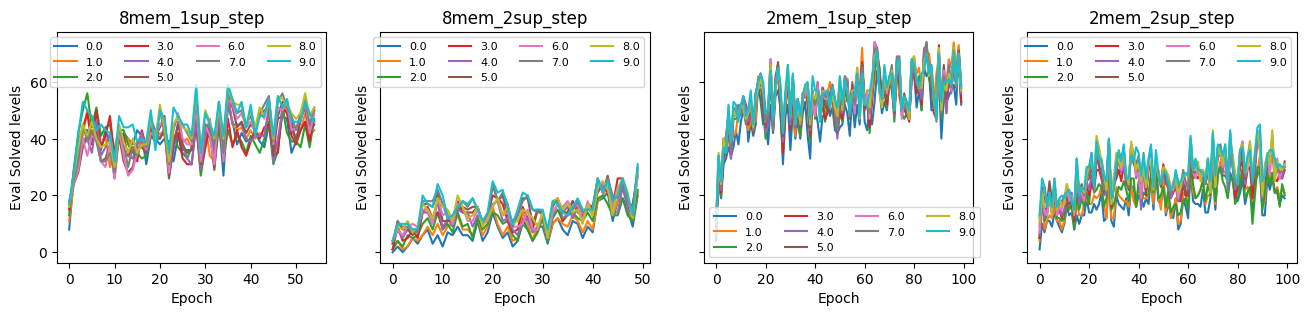

In [3]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1, 4, figsize=(4*4,3), sharey=True)


for e, exp_id in enumerate(metrics_per_exp.keys()):
    ax = axs[e]   
    df = metrics_per_exp[exp_id]

    metric_name = "eval_acc"
    type_acc = "gen"

    subdf = df[(df["metric"] == metric_name) & (df["type"] == type_acc)]
    for num_sup_steps in subdf["num_supervision_steps"].unique():
        o = subdf[subdf["num_supervision_steps"] == num_sup_steps]
        ax.plot(o["epoch"], o["value"], label=num_sup_steps)
        ax.set_ylabel("Eval Solved levels")
        ax.set_xlabel("Epoch")

    ax.legend(ncols=4, fontsize=8)

    ax.set_title(exp_id)


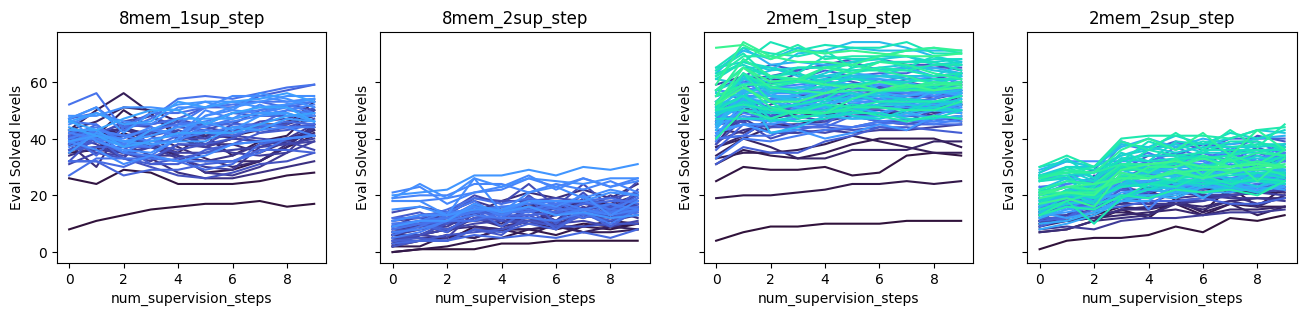

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(4*4,3), sharey=True)

for e, exp_id in enumerate(metrics_per_exp.keys()):
    ax = axs[e]   
    df = metrics_per_exp[exp_id]

    metric_name = "eval_acc"
    type_acc = "gen"
        
    subdf = df[(df["metric"] == metric_name) & (df["type"] == type_acc)]
    cmap = plt.cm.turbo

    for epoch in subdf["epoch"].unique():
        o = subdf[subdf["epoch"] == epoch]
        ax.plot(o["num_supervision_steps"], o["value"], label=epoch, color=cmap(epoch))
    ax.set_ylabel("Eval Solved levels")
    ax.set_xlabel("num_supervision_steps")

    # ax.legend(ncols=4, fontsize=8)
    ax.set_title(exp_id)

#axs.legend(ncols=2)

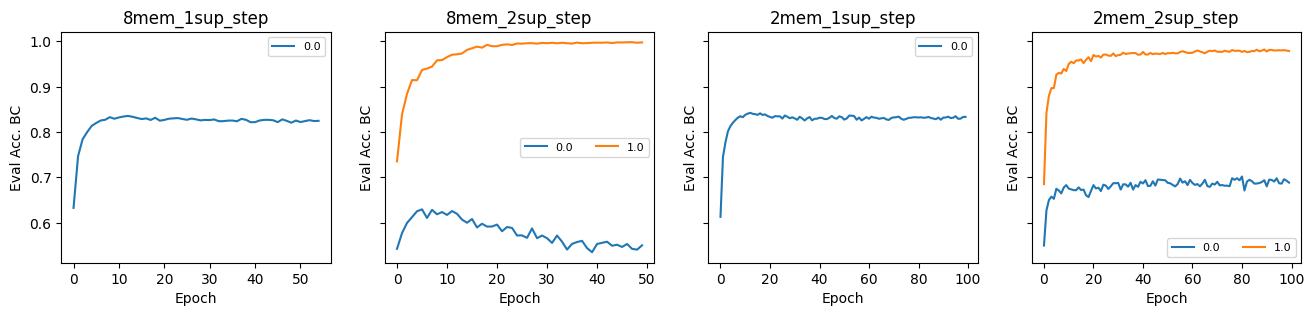

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(4*4,3), sharey=True)


for e, exp_id in enumerate(metrics_per_exp.keys()):
    ax = axs[e]   
    df = metrics_per_exp[exp_id]
    

    metric_name = "eval_acc"
    type_acc = "bc"

    subdf = df[(df["metric"] == metric_name) & (df["type"] == type_acc)]
    for num_sup_steps in subdf["num_supervision_steps"].unique():
        o = subdf[subdf["num_supervision_steps"] == num_sup_steps]
        ax.plot(o["epoch"], o["value"], label=num_sup_steps)

    ax.set_ylabel("Eval Acc. BC")
    ax.set_xlabel("Epoch")

    ax.legend(ncols=4, fontsize=8)

    ax.set_title(exp_id)

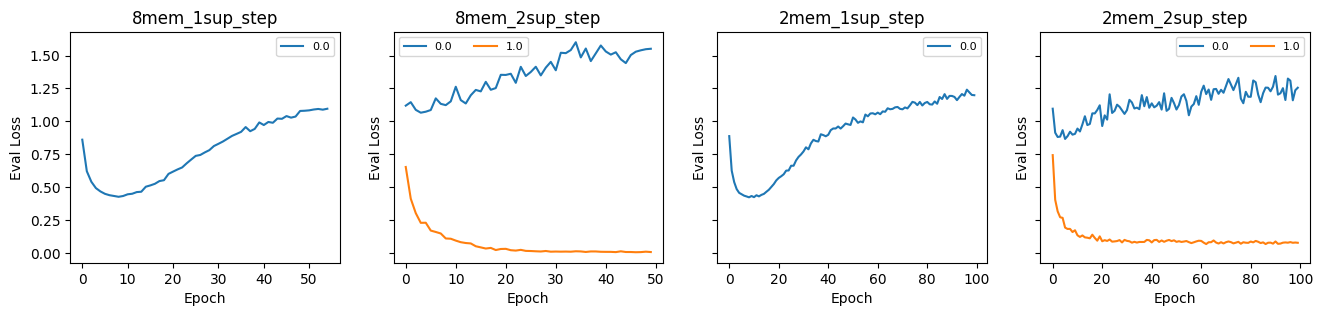

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(4*4,3), sharey=True)


for e, exp_id in enumerate(metrics_per_exp.keys()):
    ax = axs[e]   
    df = metrics_per_exp[exp_id]

    metric_name = "eval_loss"   
    subdf = df[(df["metric"] == metric_name)]
    for num_sup_steps in subdf["num_supervision_steps"].unique():
        o = subdf[subdf["num_supervision_steps"] == num_sup_steps]

        ax.plot(o["epoch"], o["value"], label=num_sup_steps)

    ax.set_ylabel("Eval Loss")
    ax.set_xlabel("Epoch")

    ax.legend(ncols=4, fontsize=8)
  
    ax.set_title(exp_id)

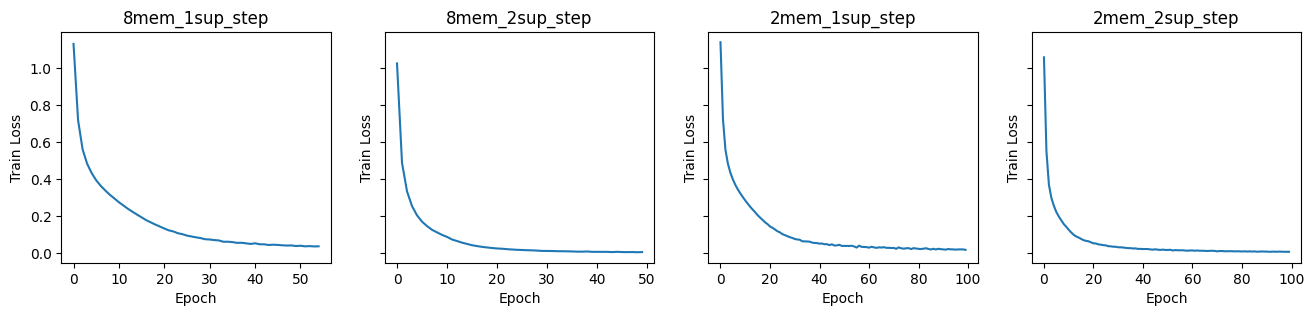

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(4*4,3), sharey=True)


for e, exp_id in enumerate(metrics_per_exp.keys()):
    ax = axs[e]   
    df = metrics_per_exp[exp_id]

    metric_name = "train_loss"   
    subdf = df[(df["metric"] == metric_name)]
    o = subdf

    ax.plot(o["epoch"], o["value"])

    ax.set_ylabel("Train Loss")
    ax.set_xlabel("Epoch")
  
    ax.set_title(exp_id)